In [1]:
# Disable JAXFEM logging
import jax_fem                       # forces setup_logger() to run NOW
import logging
jl = logging.getLogger('jax_fem')
jl.setLevel(logging.WARNING)         # or logging.ERROR to also silence INFO
jl.handlers.clear()                  # remove jax_fem's own StreamHandler
jl.propagate = False

import os, glob
import numpy as np
import pyvista as pv
from simsopt import load, save
from simsopt.configs import get_data
from simsopt.geo import plot, CurveLength
from simsopt.field import (
    BiotSavart, Current,
    coils_via_symmetries,
    RegularizedCoil, LpCurveForce,
)
from coilforce.support import CoilSupportDiscrete, CoilSupportTopBottom
from coilforce.simsopt_bridge import CoilFEMObjective
from optimization import (
    load_eq, 
    run_filament_free, 
    increase_base_curve_order,
    mesh_options,
    problem_options,
    material_options_const_temp,
    material_options_variable_temp,
)

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



In [2]:
eq, Bnormal_plasma, plasma_surface_vc, vc = load_eq('wout.nc')
curves, currents, axis, nfp, bs = get_data('w7x', coil_order=10, points_per_period=8)
coils_w7x = coils_via_symmetries(curves[:5], currents[:5], nfp, True)
coils_support = load('../w7x-optimization/coils_support.json') # Corresponds to case (A)
coils_fixed = load('coils_fixed.json')     # Corresponds to case (B)
coils_movable = load('coils_movable.json') # Corresponds to case (C)
coils_force = load('coils_force.json')     # Corresponds to case (D)
Jstress_support = load('../w7x-optimization/Jstress_support.json')[0]
Jstress_fixed = load('Jstress_fixed.json')[0]
Jstress_movable = load('Jstress_movable.json')[0]

Jstress_w7x = CoilFEMObjective(
    base_curves      = [c.curve for c in coils_w7x[:5]],
    base_currents    = [c.current for c in coils_w7x[:5]],
    base_supports    = [
        CoilSupportTopBottom(
            clamp_radius=0.3,
        ) for _ in range(5)
    ],
    metrics          = ('l2_von_mises',),
    metric_weights   = (1.,),
    nfp              = nfp,
    stellsym         = True,
    mesh_options     = mesh_options,
    material_options = material_options_const_temp,
    problem_options  = problem_options,
)
Jstress_force = CoilFEMObjective(
    base_curves      = [c.curve for c in coils_force[:5]],
    base_currents    = [c.current for c in coils_force[:5]],
    base_supports    = [
        CoilSupportTopBottom(
            clamp_radius=0.3,
        ) for _ in range(5)
    ],
    metrics          = ('l2_von_mises',),
    metric_weights   = (1.,),
    nfp              = nfp,
    stellsym         = True,
    mesh_options     = mesh_options,
    material_options = material_options_const_temp,
    problem_options  = problem_options,
)

In [3]:
from pathlib import Path

folder_path = Path('fem_data_support')
if not folder_path.is_dir():
    Jstress_w7x.save_run_vtu('fem_data_w7x', prefix='coil_')
    Jstress_fixed.save_run_vtu('fem_data_fixed', prefix='coil_')
    Jstress_force.save_run_vtu('fem_data_force', prefix='coil_')
    Jstress_movable.save_run_vtu('fem_data_movable', prefix='coil_')
    Jstress_support.save_run_vtu('fem_data_support', prefix='coil_')

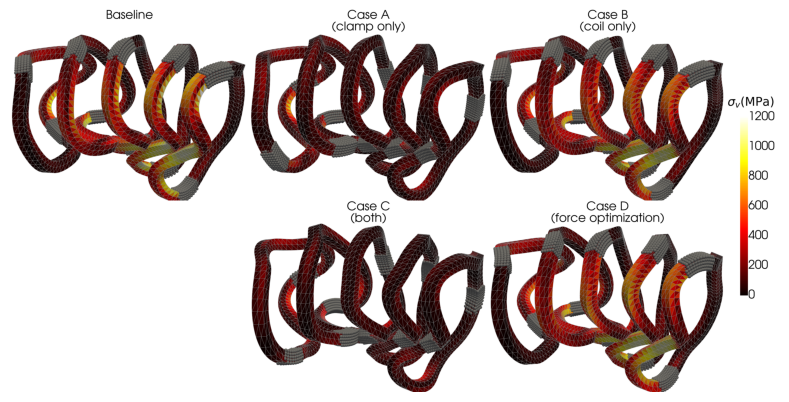

In [4]:
import os, glob
import numpy as np
import pyvista as pv
import vtk   # for custom colorbar tick labels

# ---- edit these ----
folders = [
    'fem_data_w7x',
    'fem_data_support',
    'fem_data_fixed',
    'fem_data_movable',
    'fem_data_force',
]
names = {
    'fem_data_w7x': 'Baseline',
    'fem_data_support': 'Case A\n(clamp only)',
    'fem_data_fixed': 'Case B\n(coil only)',
    'fem_data_movable': 'Case C\n(both)',
    'fem_data_force': 'Case D\n(force optimization)',
}
quantities = ['von_mises_MPa']            # your 3 cell-data array names

names_quantities = {
    'von_mises_MPa': r'$\sigma_v$',
}
# --------------------

# Load each folder's 5 vtu files once and merge them into a single object
meshes = {}
for f in folders:
    parts = [pv.read(p) for p in sorted(glob.glob(os.path.join(f, '*.vtu')))]
    meshes[f] = pv.merge(parts)        # all 5 meshes -> one combined mesh

def values(mesh, q):                   # handle scalar OR vector/tensor cell data
    a = np.asarray(mesh.cell_data[q])
    return np.linalg.norm(a, axis=1) if a.ndim == 2 and a.shape[1] > 1 else a.ravel()

# ---- camera / layout knobs ----
zoom        = 1.9     # >1 zooms in, <1 zooms out
azimuth_deg = 180     # rotate camera around the origin in the xy-plane
panel_px    = 1200     # square subplot size (pixels) -> window is (panel_px*N, panel_px)
glyph_scale = 0.02     # sphere radius [m] at support_weight == 1 (0 disables glyphs)
edge_angle  = 15      # deg; larger -> fewer edges kept (only sharper creases)
tick_interval = 200   # colorbar tick spacing (data units, e.g. MPa)
# --------------------------------

# ---- element-edge (tet10 wireframe) knobs ----
show_element_edges = True     # overlay the true quadratic element edges
edge_color         = 'grey'
edge_width         = 1.0
edge_opacity       = 1.0
edge_subdiv        = 8        # straight segments per quadratic edge (higher -> smoother curves)
edge_dedup         = True     # draw each shared edge only once
# ----------------------------------------------

def surface_edges(mesh, angle):
    """Clean wireframe: boundary + feature (crease) edges of the outer surface.

    Avoids the tet-diagonal clutter you get from add_mesh(show_edges=True)."""
    return mesh.extract_surface().extract_feature_edges(
        feature_angle=angle,
        boundary_edges=True,
        feature_edges=True,
        manifold_edges=False,
        non_manifold_edges=False,
    )

# VTK quadratic-tetra local node order for the 6 element edges: (corner_a, midside, corner_b)
_TET10_EDGES = np.array([
    [0, 4, 1],
    [1, 5, 2],
    [2, 6, 0],
    [0, 7, 3],
    [1, 8, 3],
    [2, 9, 3],
], dtype=np.int64)

def tet10_edge_lines(mesh, n_sub=8, dedup=True):
    """True curved edges of a quadratic-tetrahedron (tet10) mesh.

    Every element has 6 quadratic edges (2 corner nodes + 1 mid-side node). Each
    edge is sampled with ``n_sub`` straight segments via the quadratic shape
    functions, so the parabolic curvature carried by the mid-side node is drawn
    faithfully -- unlike add_mesh(show_edges=True), which draws the tessellation
    diagonals, or a plain corner-to-corner wireframe, which ignores the curvature.

    Only VTK_QUADRATIC_TETRA (type 24) cells contribute. Returns a PolyData of
    polylines; each shared edge is drawn once when ``dedup`` is True.
    """
    cd = mesh.cells_dict
    if 24 not in cd:                        # nothing quadratic -> fall back to straight edges
        return mesh.extract_all_edges()

    cells = np.asarray(cd[24])              # (m, 10) tet10 connectivity
    edges = cells[:, _TET10_EDGES].reshape(-1, 3)   # (6m, 3): corner_a, mid, corner_b

    if dedup:                               # keep each undirected corner pair once
        key = np.sort(edges[:, ::2], axis=1)
        _, keep = np.unique(key, axis=0, return_index=True)
        edges = edges[keep]

    pts = np.asarray(mesh.points, dtype=float)
    p0, pm, p1 = pts[edges[:, 0]], pts[edges[:, 1]], pts[edges[:, 2]]

    # quadratic Lagrange basis for nodes at t = 0, 0.5, 1
    t  = np.linspace(0.0, 1.0, n_sub + 1)
    N0 = (2.0 * t - 1.0) * (t - 1.0)
    Nm = 4.0 * t * (1.0 - t)
    N1 = t * (2.0 * t - 1.0)
    sample = (N0[None, :, None] * p0[:, None, :]
              + Nm[None, :, None] * pm[:, None, :]
              + N1[None, :, None] * p1[:, None, :])       # (E, S, 3)

    E, S  = edges.shape[0], n_sub + 1
    ids   = np.arange(E * S, dtype=np.int64).reshape(E, S)
    lines = np.hstack([np.full((E, 1), S, dtype=np.int64), ids]).ravel()
    return pv.PolyData(sample.reshape(-1, 3), lines=lines)

def make_support_glyphs(mesh, scale):
    """Grey sphere glyphs at supported nodes, radius proportional to weight."""
    if scale <= 0 or "support_weights" not in mesh.point_data:
        return None
    w = np.asarray(mesh.point_data["support_weights"]).ravel()
    mask = w > 0.0
    if not mask.any():
        return None
    cloud = pv.PolyData(np.asarray(mesh.points)[mask])
    cloud["support_weights"] = w[mask]
    # pv.Sphere has radius 0.5, so factor=2*scale gives radius==scale at weight 1
    sphere = pv.Sphere(theta_resolution=12, phi_resolution=12)
    return cloud.glyph(scale="support_weights", geom=sphere,
                       factor=3.0 * scale, orient=False)

def rotate_camera_xy(plotter, angle_deg, center=(0.0, 0.0, 0.0)):
    '''Rotate the (shared) camera in xy about the z-axis through ``center``.'''
    th = np.radians(angle_deg)
    c, s = np.cos(th), np.sin(th)
    R = np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])
    ctr = np.asarray(center, dtype=float)
    cam = plotter.camera
    cam.position    = tuple(ctr + R @ (np.asarray(cam.position)    - ctr))
    cam.focal_point = tuple(ctr + R @ (np.asarray(cam.focal_point) - ctr))
    cam.up          = tuple(R @ np.asarray(cam.up))   # direction: no translation

# Rotation center = mean of all vertices across all coils/folders
center = np.vstack([np.asarray(meshes[f].points) for f in folders]).mean(axis=0) + np.array([0,0.2,0])

# Precompute the tet10 wireframe once per folder (independent of the quantity)
edge_lines = ({f: tet10_edge_lines(meshes[f], n_sub=edge_subdiv, dedup=edge_dedup)
               for f in folders} if show_element_edges else {})

# One figure per quantity
for q in quantities:
    allvals = np.concatenate([values(meshes[f], q) for f in folders])
    clim = (0, float(allvals.max()))   # shared color range across panels

    # 2-row layout; bottom-left cell left empty:
    #   row 0: panels 0, 1, 2
    #   row 1:  _ ,  3, 4
    nrows, ncols = 2, 3
    positions = [(0, 0), (0, 1), (0, 2), (1, 1), (1, 2)]
    panel_h = int(panel_px * 0.8)
    # Extra narrow column (spanning both rows) holds one shared colorbar.
    cbar_col  = ncols
    cbar_frac = 0.22        # colorbar column width relative to a panel
    p = pv.Plotter(shape=(nrows, ncols + 1), off_screen=True,
                   groups=[(np.s_[:], cbar_col)],          # colorbar spans all rows
                   col_weights=[1.0] * ncols + [cbar_frac],
                   window_size=(int(panel_px * (ncols + cbar_frac)), panel_h * nrows),
                   border=False)        # no black border between subplots
    for i, f in enumerate(folders):
        p.subplot(*positions[i])
        p.add_text(names[f], font_size=25, position='upper_edge')
        actor = p.add_mesh(
            meshes[f], scalars=q, preference='cell', clim=clim,
            cmap='hot',
            show_scalar_bar=False,      # shared bar drawn separately below
        )
        bar_mapper = actor.mapper       # all panels share clim/cmap -> any mapper works

        # --- overlay the true tet10 element edges ---
        if show_element_edges:
            ea = p.add_mesh(edge_lines[f], color=edge_color, line_width=edge_width,
                            opacity=edge_opacity, show_scalar_bar=False)
            # nudge the wire in front of the shaded surface to stop z-fighting
            try:
                ea.mapper.SetResolveCoincidentTopologyToPolygonOffset()
                ea.mapper.SetRelativeCoincidentTopologyLineOffsetParameters(-1.0, -1.0)
            except Exception:
                pass

        glyphs = make_support_glyphs(meshes[f], glyph_scale)
        if glyphs is not None:
            p.add_mesh(glyphs, color="grey", show_scalar_bar=False)
    # Link/orient only the panel cameras (not the colorbar renderer).
    p.link_views()
    p.subplot(0, 0)             # make a panel active before setting the view
    p.view_isometric()         # or p.view_xy(), p.view_xz(), etc.
    rotate_camera_xy(p, azimuth_deg, center=center)
    p.camera.zoom(zoom)

    # ---- one shared colorbar, vertically centered in the right column ----
    p.subplot(0, cbar_col)
    sb = p.add_scalar_bar(
        title=r"$\sigma_v$(MPa)",
        mapper=bar_mapper,
        vertical=True,
        position_x=0.24, position_y=0.25,
        height=0.5, width=0.4,
        title_font_size=60,
        label_font_size=60,
        fmt="%.0f",
    )
    ticks = np.arange(0.0, clim[1] + 1e-9, tick_interval)   # 0, 200, 400, ...
    labels = vtk.vtkDoubleArray()
    labels.SetNumberOfValues(len(ticks))
    for k, t in enumerate(ticks):
        labels.SetValue(k, float(t))
    sb.SetUseCustomLabels(True)
    sb.SetCustomLabels(labels)
    img = p.screenshot(f'../figures/figure_{q}.png')   # also returns the rendered RGB array
    p.close()

    # ---- preview inline in the notebook ----
    import matplotlib.pyplot as plt
    ih, iw = img.shape[:2]
    fig, ax = plt.subplots(figsize=(10, 10 * ih / iw))
    ax.imshow(img)
    ax.axis('off')
    # ax.set_title(q)
    plt.show()

pv.close_all()
plt.close('all')

In [ ]:
# ── Thermal vs elastic von Mises stress (movable configuration) ──────────────
# Two side-by-side panels sharing one colorbar.  Reuses the exact camera angle,
# zoom, tet10 edges, glyphs and cmap set up in the big figure cell above
# (values, tet10_edge_lines/edge_lines, make_support_glyphs, rotate_camera_xy,
# center, zoom, azimuth_deg, panel_px, glyph_scale and the edge_* knobs).
import math

folder_mov = 'fem_data_movable'
mesh_mov   = meshes[folder_mov]
panels_te  = [
    ('von_mises_thermal_MPa', 'thermal'),
    ('von_mises_elastic_MPa', 'elastic'),
]

# One shared color range spanning both fields.
allvals = np.concatenate([values(mesh_mov, q) for q, _ in panels_te])
clim = (0.0, float(allvals.max()))

# Reuse the precomputed tet10 wireframe if available, else build it once.
edges_mov = edge_lines.get(folder_mov) if show_element_edges else None
if show_element_edges and edges_mov is None:
    edges_mov = tet10_edge_lines(mesh_mov, n_sub=edge_subdiv, dedup=edge_dedup)

ncols     = 2
cbar_frac = 0.22
panel_h   = int(panel_px * 0.8)
p = pv.Plotter(shape=(1, ncols + 1), off_screen=True,
               groups=[(np.s_[:], ncols)],                 # colorbar column
               col_weights=[1.0] * ncols + [cbar_frac],
               window_size=(int(panel_px * (ncols + cbar_frac)), panel_h),
               border=False)
for i, (q, title) in enumerate(panels_te):
    p.subplot(0, i)
    p.add_text(title, font_size=25, position='upper_edge')
    actor = p.add_mesh(mesh_mov, scalars=q, preference='cell', clim=clim,
                       cmap='hot', show_scalar_bar=False)
    bar_mapper = actor.mapper
    if show_element_edges:
        ea = p.add_mesh(edges_mov, color=edge_color, line_width=edge_width,
                        opacity=edge_opacity, show_scalar_bar=False)
        try:
            ea.mapper.SetResolveCoincidentTopologyToPolygonOffset()
            ea.mapper.SetRelativeCoincidentTopologyLineOffsetParameters(-1.0, -1.0)
        except Exception:
            pass
    glyphs = make_support_glyphs(mesh_mov, glyph_scale)
    if glyphs is not None:
        p.add_mesh(glyphs, color='grey', show_scalar_bar=False)

# Identical camera treatment to the last cell.
p.link_views()
p.subplot(0, 0)
p.view_isometric()
rotate_camera_xy(p, azimuth_deg, center=center)
p.camera.zoom(zoom)

# One shared colorbar with a nice round tick interval derived from the range.
p.subplot(0, ncols)
sb = p.add_scalar_bar(
    title=r"$\sigma_v$ (MPa)", mapper=bar_mapper, vertical=True,
    position_x=0.24, position_y=0.25, height=0.5, width=0.4,
    title_font_size=60, label_font_size=60, fmt="%.0f",
)
_raw = max(clim[1], 1e-9) / 4.0
_mag = 10 ** math.floor(math.log10(_raw))
tick_int = max(round(_raw / _mag) * _mag, _mag)
ticks = np.arange(0.0, clim[1] + 1e-9, tick_int)
labels = vtk.vtkDoubleArray(); labels.SetNumberOfValues(len(ticks))
for k, t in enumerate(ticks):
    labels.SetValue(k, float(t))
sb.SetUseCustomLabels(True); sb.SetCustomLabels(labels)

img = p.screenshot('../figures/figure_movable_vm_thermal_elastic.png')
p.close()

import matplotlib.pyplot as plt
ih, iw = img.shape[:2]
fig, ax = plt.subplots(figsize=(10, 10 * ih / iw))
ax.imshow(img); ax.axis('off'); plt.show()
pv.close_all(); plt.close('all')

In [ ]:
# ── RMS body-force density: gravity vs Lorentz (movable), true volume integral ─
# Volume-weighted RMS  =  sqrt( Σ_c |f_c|² V_c / Σ_c V_c )  using the actual
# tet10 element volumes V_c — a true volume integral, not an unweighted per-cell
# mean.  The saved f_vol_Npm3 is the TOTAL body force (Lorentz + gravity); gravity
# is a spatially uniform rho*g field, so the Lorentz part is f_vol - rho*g.
import json

mesh_rms = meshes['fem_data_movable']

with open('../properties.json') as _f:
    _props = json.load(_f)
rho    = float(_props['material']['density_kg_m3'])
g_vec  = np.asarray(_props['gravity']['g_vec_m_s2'], dtype=float)
f_grav = rho * g_vec                                    # uniform gravity load [N/m^3]

# True element volumes (integrates each cell; robust for the tet10 mesh).
V = np.abs(np.asarray(
    mesh_rms.compute_cell_sizes(length=False, area=False, volume=True)
    .cell_data['Volume']
))                                                      # (n_cells,)

f_vol = np.asarray(mesh_rms.cell_data['f_vol_Npm3'])    # (n_cells, 3) total
f_lor = f_vol - f_grav[None, :]                         # Lorentz-only

def vol_rms(vec):
    """Volume-weighted RMS magnitude of a per-cell vector field."""
    mag2 = np.sum(vec * vec, axis=1)
    return np.sqrt(np.sum(mag2 * V) / np.sum(V))

rms_grav = vol_rms(np.broadcast_to(f_grav, f_vol.shape))   # equals |rho*g|
rms_lor  = vol_rms(f_lor)

print("Movable configuration — volume-weighted RMS body-force density [N/m^3]")
print(f"  total mesh volume       : {V.sum():.4f} m^3")
print(f"  gravity (rho*g uniform) : {rms_grav:.4e}   (|rho*g| = {np.linalg.norm(f_grav):.4e})")
print(f"  Lorentz (f_vol - rho*g) : {rms_lor:.4e}")
print(f"  ratio Lorentz / gravity : {rms_lor / rms_grav:.1f}x")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.bar(['gravity', 'Lorentz'], [rms_grav, rms_lor], color=['tab:gray', 'tab:red'])
ax.set_yscale('log')
ax.set_ylabel(r'RMS body-force density  [N/m$^3$]')
ax.set_title('Movable: RMS body force (volume-weighted)')
for i, val in enumerate([rms_grav, rms_lor]):
    ax.text(i, val, f'{val:.2e}', ha='center', va='bottom')
plt.tight_layout(); plt.show()